In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
#read the data
df = pd.read_csv('../csv/Titanic_cleaned.csv')
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,0,1,0,0,1
1,2,1,1,38.0,1,0,71.2833,1,0,1,0,0
2,3,1,3,26.0,0,0,7.9250,1,0,0,0,1
3,4,1,1,35.0,1,0,53.1000,1,0,0,0,1
4,5,0,3,35.0,0,0,8.0500,0,1,0,0,1


In [3]:
x = df.drop('Survived', axis=1)
y = df['Survived']

x.shape, y.shape

((891, 11), (891,))

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_valid, y_train, y_valid = train_test_split(x,y,random_state=45,stratify=y,test_size=0.25)
x_train.shape, x_valid.shape, y_train.shape, y_valid.shape

((668, 11), (223, 11), (668,), (223,))

In [6]:
from sklearn.tree import DecisionTreeClassifier

In [7]:
dt = DecisionTreeClassifier(random_state=10)

In [8]:
dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=10)

In [9]:
dt.score(x_train, y_train)

1.0

In [10]:
dt.score(x_valid, y_valid)

0.7488789237668162

In [12]:
# Okay....so wow, this is quiet an aggressive accuracy for training data. Let's try to improve our valid data accuracy.

In [13]:
train_accuracy = []
valid_accuracy = []

for depth in range(1,10):
    dt_model = DecisionTreeClassifier(max_depth=depth, random_state=10)
    dt_model.fit(x_train, y_train)
    train_accuracy.append(dt_model.score(x_train, y_train))
    valid_accuracy.append(dt_model.score(x_valid, y_valid))

In [16]:
frame = pd.DataFrame({'max_depth':range(1,10), 'train_acc': train_accuracy, 'valid_acc': valid_accuracy})
frame.head()

,max_depth,train_acc,valid_acc
0,1,0.790419,0.775785
1,2,0.790419,0.775785
2,3,0.815868,0.793722
3,4,0.827844,0.829596
4,5,0.856287,0.793722


In [17]:
#plotting this data as a graph to visualize!

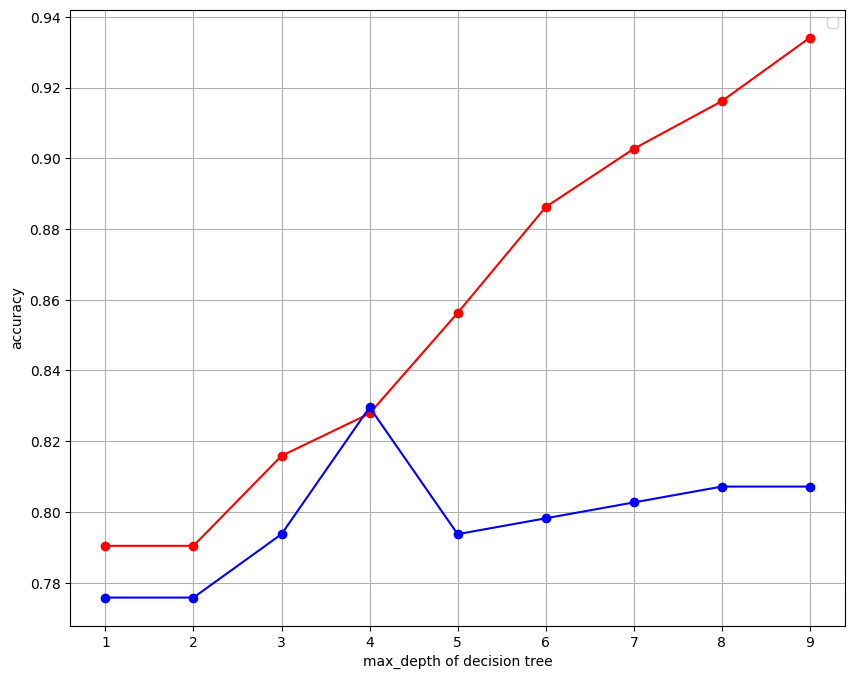

In [18]:
plt.figure(figsize=(10,8))
plt.plot(frame['max_depth'], frame['train_acc'], color='red', marker='o')
plt.plot(frame['max_depth'], frame['valid_acc'], color='blue', marker='o')
plt.xlabel('max_depth of decision tree')
plt.ylabel('accuracy')
plt.legend()
plt.grid()

In [19]:
# Clearly, at depth=4, we got the best measures of both the accuracy scores.

In [20]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=10)

In [21]:
dt_model.fit(x_train, y_train)
dt_model.score(x_train, y_train)

0.8278443113772455

In [22]:
dt_model.score(x_valid,y_valid)

0.8295964125560538

In [23]:
# Now, let's plot the decision tree graph as well!

In [24]:
from sklearn import tree

In [25]:
decision_tree = tree.export_graphviz(dt_model, out_file='tree.dot', feature_names=x_train.columns, max_depth=4,filled=True)

In [27]:
!dot -Tpng tree.dot -o tree.png

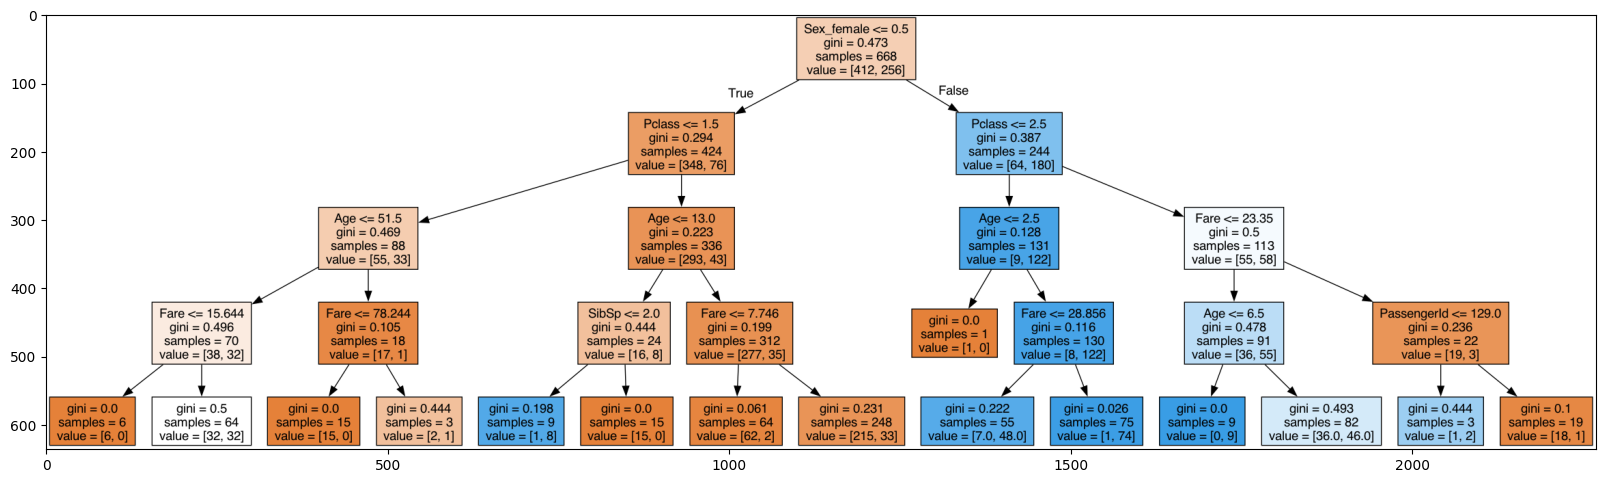

In [30]:
image = plt.imread('tree.png')
plt.figure(figsize=(20,20))
plt.imshow(image)